In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from itertools import combinations

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
df = pd.read_csv('constructs_df.csv', index_col=0)

In [3]:
def plot_invitro_vs_cell(df, constructs, figsize=(2.5, 4), top=0.6, bot=0,
                         ylabel='$E_f$'):
    """
    Plot in vitro vs in-cell FRET efficiency with constructs on x-axis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing columns: 'construct', 'Ef_cell', 'Ef_cell_std', 'Ef_invitro', 'Ef_invitro_std', 'n_wells'
    constructs : list
        List of construct identifiers to plot (in desired order)
    figsize : tuple, default=(8, 6)
        Figure size (width, height)
    top : float, default=0.6
        Top limit of y-axis
    bot : float, default=0
        Bottom limit of y-axis
    ylabel : str, default='FRET Efficiency ($E_f$)'
        Y-axis label
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    
    # Filter dataframe for specified constructs
    plot_df = df[df['construct'].isin(constructs)].copy()
    
    # Ensure constructs are in the specified order
    plot_df['construct'] = pd.Categorical(plot_df['construct'], 
                                          categories=constructs, 
                                          ordered=True)
    plot_df = plot_df.sort_values('construct')
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create x positions for each construct
    x_positions = np.arange(len(constructs))
    
    # Collect data for line plotting
    invitro_x = []
    invitro_y = []
    cell_x = []
    cell_y = []
    
    # Store construct data for significance testing
    construct_data_list = []
    
    # Plot each construct
    for idx, (x_pos, construct) in enumerate(zip(x_positions, constructs)):
        construct_data = plot_df[plot_df['construct'] == construct].iloc[0]
        
        # Get values
        ef_invitro = construct_data['Ef_invitro']
        ef_invitro_std = construct_data['Ef_invitro_std']
        ef_cell = construct_data['Ef_cell']
        ef_cell_std = construct_data['Ef_cell_std']
        n_wells = construct_data['n_wells']
        
        # Store data for lines and significance testing
        invitro_x.append(x_pos)
        invitro_y.append(ef_invitro)
        cell_x.append(x_pos)
        cell_y.append(ef_cell)
        
        construct_data_list.append({
            'x_pos': x_pos,
            'ef_invitro': ef_invitro,
            'ef_invitro_std': ef_invitro_std,
            'ef_cell': ef_cell,
            'ef_cell_std': ef_cell_std,
            'n_wells': n_wells,
            'n_invitro': 3
        })
        
        # Plot in vitro point (triangle) at x_pos with grey error bars - PURPLE
        ax.errorbar(x_pos, ef_invitro, yerr=ef_invitro_std,
                   fmt='^', color='purple', markersize=11, capsize=7,
                   linewidth=2, capthick=2, alpha=0.8, ecolor='grey', barsabove=False,
                   label='In Vitro' if idx == 0 else '')
        
        # Plot in cell point (circle) at x_pos with grey error bars - GREEN
        ax.errorbar(x_pos, ef_cell, yerr=ef_cell_std,
                   fmt='o', color='green', markersize=11, capsize=7,
                   linewidth=2, capthick=2, alpha=0.8, ecolor='grey', barsabove=False,
                   label='In Cell' if idx == 0 else '')
    
    # Draw lines connecting triangles (in vitro) across constructs
    ax.plot(invitro_x, invitro_y, color='grey', linestyle='-', 
            linewidth=1.5, alpha=0.6, zorder=0)
    
    # Draw lines connecting circles (in cell) across constructs
    ax.plot(cell_x, cell_y, color='grey', linestyle='-', 
            linewidth=1.5, alpha=0.6, zorder=0)
    
    # Perform significance testing between constructs
    if len(constructs) == 2:
        data1 = construct_data_list[0]
        data2 = construct_data_list[1]
        
        # Welch's t-test for in vitro data
        # Calculate t-statistic and p-value manually
        mean1_iv = data1['ef_invitro']
        std1_iv = data1['ef_invitro_std']
        n1_iv = data1['n_invitro']
        
        mean2_iv = data2['ef_invitro']
        std2_iv = data2['ef_invitro_std']
        n2_iv = data2['n_invitro']
        
        # Welch's t-test calculation
        se1_iv = std1_iv / np.sqrt(n1_iv)
        se2_iv = std2_iv / np.sqrt(n2_iv)
        se_diff_iv = np.sqrt(se1_iv**2 + se2_iv**2)
        t_stat_iv = (mean1_iv - mean2_iv) / se_diff_iv
        
        # Degrees of freedom (Welch-Satterthwaite equation)
        dof_iv = (se1_iv**2 + se2_iv**2)**2 / (se1_iv**4 / (n1_iv - 1) + se2_iv**4 / (n2_iv - 1))
        p_value_iv = 2 * (1 - stats.t.cdf(abs(t_stat_iv), dof_iv))
        
        # Welch's t-test for in cell data
        mean1_cell = data1['ef_cell']
        std1_cell = data1['ef_cell_std']
        n1_cell = data1['n_wells']
        
        mean2_cell = data2['ef_cell']
        std2_cell = data2['ef_cell_std']
        n2_cell = data2['n_wells']
        
        se1_cell = std1_cell / np.sqrt(n1_cell)
        se2_cell = std2_cell / np.sqrt(n2_cell)
        se_diff_cell = np.sqrt(se1_cell**2 + se2_cell**2)
        t_stat_cell = (mean1_cell - mean2_cell) / se_diff_cell
        
        dof_cell = (se1_cell**2 + se2_cell**2)**2 / (se1_cell**4 / (n1_cell - 1) + se2_cell**4 / (n2_cell - 1))
        p_value_cell = 2 * (1 - stats.t.cdf(abs(t_stat_cell), dof_cell))
        
        # Convert p-values to significance symbols
        def p_to_symbol(p):
            if p > 0.05:
                return 'ns'
            elif p > 0.01:
                return '*'
            elif p > 0.001:
                return '**'
            elif p > 0.0001:
                return '***'
            else:
                return '****'
        
        sig_symbol_iv = p_to_symbol(p_value_iv)
        sig_symbol_cell = p_to_symbol(p_value_cell)
        
        # Calculate angle and position for in vitro significance label
        dx_iv = data2['x_pos'] - data1['x_pos']
        dy_iv = mean2_iv - mean1_iv
        angle_iv = 5 * np.degrees(np.arctan2(dy_iv, dx_iv))
        mid_x_iv = (data1['x_pos'] + data2['x_pos']) / 2
        mid_y_iv = (mean1_iv + mean2_iv) / 2 - .01  # Offset above line
        
        # Calculate angle and position for in cell significance label
        dx_cell = data2['x_pos'] - data1['x_pos']
        dy_cell = mean2_cell - mean1_cell
        angle_cell = 7 * np.degrees(np.arctan2(dy_cell, dx_cell))
        mid_x_cell = (data1['x_pos'] + data2['x_pos']) / 2
        mid_y_cell = (mean1_cell + mean2_cell) / 2 - .01  # Offset above line
        
        # Add significance labels
        ax.text(mid_x_iv, mid_y_iv, sig_symbol_iv, 
               fontsize=12, ha='center', va='bottom',
               rotation=angle_iv, color='purple', fontweight='bold')
        
        ax.text(mid_x_cell, mid_y_cell, sig_symbol_cell, 
               fontsize=12, ha='center', va='bottom',
               rotation=angle_cell, color='green', fontweight='bold')
    
    # Formatting
    ax.set_xlim(-0.5, len(constructs) - 0.5)
    ax.set_ylim(bot, top)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([])  # Remove x-tick labels
    ax.set_xlabel('')
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add construct labels inside the plot, just above baseline
    y_range = top - bot
    for i, construct in enumerate(constructs):
        ax.text(i, bot + y_range * 0.01, 
               f'#{construct}', ha='center', va='bottom', 
               fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    
    return fig, ax

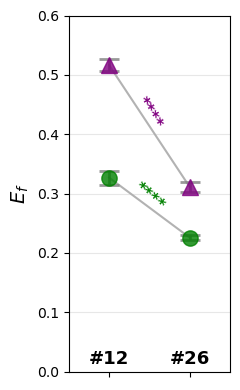

In [4]:
constructs_to_plot = [12, 26]
plot_invitro_vs_cell(df, constructs_to_plot)
plt.savefig('Figure_graphs/FigSI/Invitro-Incell/12-26_IV.svg')

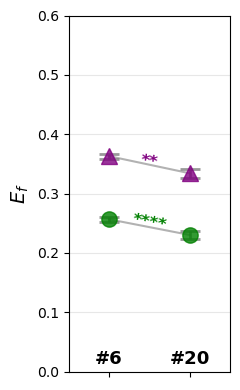

In [5]:
constructs_to_plot = [6, 20]
plot_invitro_vs_cell(df, constructs_to_plot)
plt.savefig('Figure_graphs/FigSI/Invitro-Incell/6-20_IV.svg')

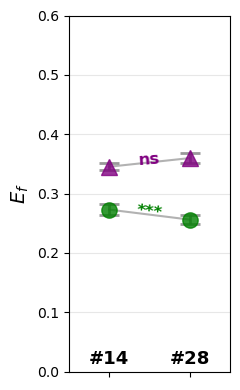

In [6]:
constructs_to_plot = [14, 28]
plot_invitro_vs_cell(df, constructs_to_plot)
plt.savefig('Figure_graphs/FigSI/Invitro-Incell/14-28_IV.svg')

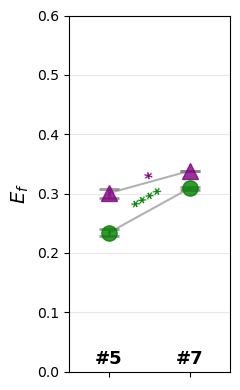

In [7]:
constructs_to_plot = [5, 7]
plot_invitro_vs_cell(df, constructs_to_plot)
plt.savefig('Figure_graphs/FigSI/Invitro-Incell/5-7_IV.svg')

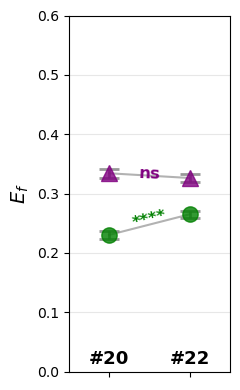

In [8]:
constructs_to_plot = [20, 22]
plot_invitro_vs_cell(df, constructs_to_plot)
plt.savefig('Figure_graphs/FigSI/Invitro-Incell/20-22_IV.svg')

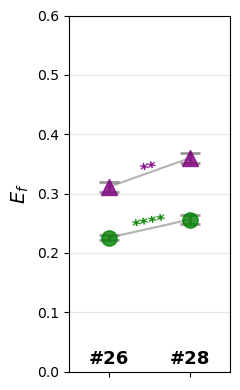

In [9]:
constructs_to_plot = [26, 28]
plot_invitro_vs_cell(df, constructs_to_plot)
plt.savefig('Figure_graphs/FigSI/Invitro-Incell/26-28_IV.svg')

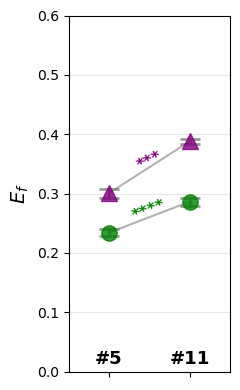

In [10]:
constructs_to_plot = [5, 11]
plot_invitro_vs_cell(df, constructs_to_plot)
plt.savefig('Figure_graphs/FigSI/Invitro-Incell/5-11_IV.svg')

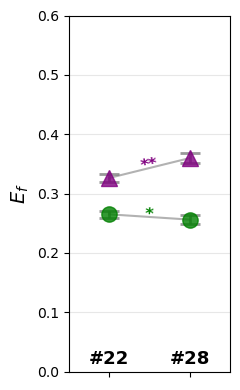

In [11]:
constructs_to_plot = [22, 28]
plot_invitro_vs_cell(df, constructs_to_plot)
plt.savefig('Figure_graphs/FigSI/Invitro-Incell/22-28_IV.svg')

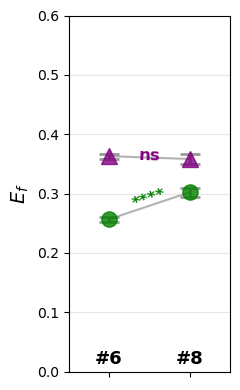

In [12]:
constructs_to_plot = [6, 8]
plot_invitro_vs_cell(df, constructs_to_plot)
plt.savefig('Figure_graphs/FigSI/Invitro-Incell/6-8_IV.svg')